<a href="https://colab.research.google.com/github/JCelisR/bootcamp/blob/main/Tarea%205_Modulo%209.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, IntegerType, DoubleType
import random

# 1. Iniciar sesión de Spark
spark = SparkSession.builder \
    .appName("RetailMax_ML_Pipeline") \
    .getOrCreate()

# 2. Generar datos simulados
num_records = 5000
data = []

for i in range(num_records):
    user_id = i

    # Características (Features)
    paginas_visitadas = random.randint(1, 100) # Registros de navegación
    compras_previas = random.randint(0, 15)    # Historial de compras
    calificacion_promedio = round(random.uniform(1.0, 5.0), 1) # Calificaciones de productos

    # Etiqueta objetivo (Target / Label)
    # Creamos una regla lógica simple para que el modelo tenga un patrón que aprender:
    # A mayor navegación y más compras previas, mayor probabilidad de compra futura.
    probabilidad = (paginas_visitadas * 0.01) + (compras_previas * 0.05)
    comprara_proximos_dias = 1 if random.random() < probabilidad else 0

    data.append((user_id, paginas_visitadas, compras_previas, calificacion_promedio, comprara_proximos_dias))

# 3. Definir el esquema de los datos
schema = StructType([
    StructField("user_id", IntegerType(), True),
    StructField("paginas_visitadas", IntegerType(), True),
    StructField("compras_previas", IntegerType(), True),
    StructField("calificacion_promedio", DoubleType(), True),
    StructField("label", IntegerType(), True) # Etiqueta objetivo requerida por MLlib
])

# 4. Crear el DataFrame
df_ecommerce = spark.createDataFrame(data, schema)

# Mostrar los primeros registros para verificar
print("Muestra del Dataset Simulado:")
df_ecommerce.show(5)

Muestra del Dataset Simulado:
+-------+-----------------+---------------+---------------------+-----+
|user_id|paginas_visitadas|compras_previas|calificacion_promedio|label|
+-------+-----------------+---------------+---------------------+-----+
|      0|               16|             14|                  2.2|    1|
|      1|               51|             12|                  2.9|    1|
|      2|                4|              0|                  3.6|    0|
|      3|               40|             15|                  3.9|    1|
|      4|               74|              9|                  2.3|    1|
+-------+-----------------+---------------+---------------------+-----+
only showing top 5 rows


In [2]:
from pyspark.ml.feature import VectorAssembler

# 1. Definir qué columnas son nuestras "características" predictoras
feature_columns = ["paginas_visitadas", "compras_previas", "calificacion_promedio"]

# 2. Configurar el ensamblador (VectorAssembler)
assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features" # Este es el nombre estándar que MLlib espera por defecto
)

# 3. Transformar nuestro DataFrame simulado
# Esto añadirá una nueva columna llamada "features" al final de la tabla
df_vectorizado = assembler.transform(df_ecommerce)

# Mostrar el resultado, seleccionando solo lo que el modelo necesita ver
print("Dataset listo para entrenar (Vectorizado):")
df_vectorizado.select("user_id", "features", "label").show(5, truncate=False)

Dataset listo para entrenar (Vectorizado):
+-------+---------------+-----+
|user_id|features       |label|
+-------+---------------+-----+
|0      |[16.0,14.0,2.2]|1    |
|1      |[51.0,12.0,2.9]|1    |
|2      |[4.0,0.0,3.6]  |0    |
|3      |[40.0,15.0,3.9]|1    |
|4      |[74.0,9.0,2.3] |1    |
+-------+---------------+-----+
only showing top 5 rows


In [3]:
from pyspark.ml.classification import LogisticRegression

# 4. Dividir los datos en entrenamiento (70%) y prueba (30%)
# Usamos una semilla (seed) para que los resultados sean reproducibles
train_data, test_data = df_vectorizado.randomSplit([0.7, 0.3], seed=42)

print(f"Registros para entrenamiento: {train_data.count()}")
print(f"Registros para prueba: {test_data.count()}")

# 3. Configurar el modelo de Regresión Logística
# Indicamos cuáles son las columnas de características y la etiqueta objetivo
lr = LogisticRegression(featuresCol="features", labelCol="label")

# Entrenar el modelo con el conjunto de entrenamiento
model_lr = lr.fit(train_data)

# Realizar predicciones sobre el conjunto de prueba
predictions = model_lr.transform(test_data)

# Mostrar los resultados de la predicción
print("\nMuestra de predicciones:")
predictions.select("features", "label", "prediction", "probability").show(5)

Registros para entrenamiento: 3553
Registros para prueba: 1447

Muestra de predicciones:
+--------------+-----+----------+--------------------+
|      features|label|prediction|         probability|
+--------------+-----+----------+--------------------+
| [4.0,0.0,3.6]|    0|       0.0|[0.92915054135283...|
|[48.0,6.0,3.1]|    1|       1.0|[0.16387561577452...|
|[14.0,5.0,3.5]|    1|       0.0|[0.64481211941227...|
|[40.0,9.0,3.1]|    1|       1.0|[0.11698963564280...|
|[63.0,4.0,1.2]|    1|       1.0|[0.11689713643970...|
+--------------+-----+----------+--------------------+
only showing top 5 rows


In [4]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# 1. Configurar el evaluador para el Área bajo la curva ROC (Métrica requerida)
evaluator = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")

# 2. Definir la rejilla de parámetros (ParamGrid) para ajustar el modelo
# Probaremos diferentes niveles de regularización para evitar el sobreajuste
paramGrid = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.1, 0.01]) \
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0]) \
    .build()

# 3. Configurar la Validación Cruzada (Paso 5 de las instrucciones)
# Dividirá los datos en 3 "folds" para validar el ajuste
cv = CrossValidator(estimator=lr,
                    estimatorParamMaps=paramGrid,
                    evaluator=evaluator,
                    numFolds=3)

# 4. Entrenar el modelo optimizado
cv_model = cv.fit(train_data)

# 5. Evaluar el desempeño final (Paso 6 de las instrucciones)
final_predictions = cv_model.transform(test_data)
roc_auc = evaluator.evaluate(final_predictions)

print(f"Resultado final - Área bajo la curva ROC: {roc_auc:.4f}")

Resultado final - Área bajo la curva ROC: 0.8967


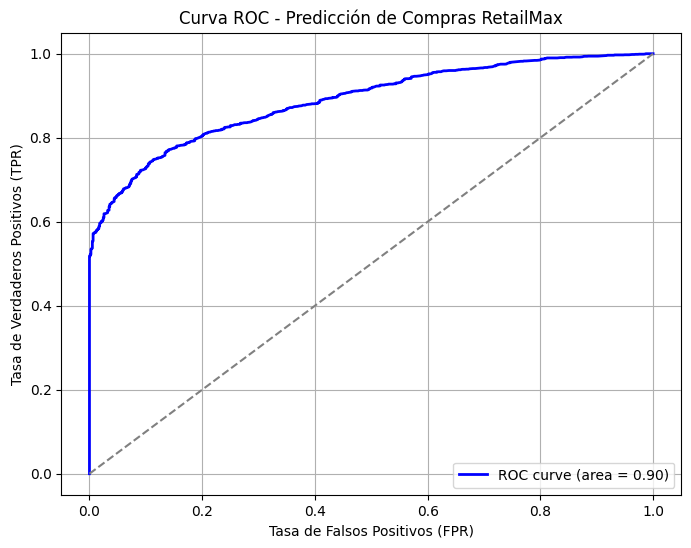

In [5]:
import matplotlib.pyplot as plt

# Extraer los datos de la curva ROC del modelo entrenado
training_summary = model_lr.summary
roc = training_summary.roc.toPandas()

# Crear el gráfico
plt.figure(figsize=(8, 6))
plt.plot(roc['FPR'], roc['TPR'], color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Predicción de Compras RetailMax')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()